Ahora vamos con segmentación de los latidos

In [1]:
import os
import wfdb
import pandas as pd
import numpy as np

Para la segmentación de latidos usamos la base de datos QTDB 

In [2]:
data_folder = os.path.join("..","data")
qtdb_dir = os.path.join(data_folder, "qtdb_data")
os.makedirs(qtdb_dir, exist_ok=True)

if not os.listdir(qtdb_dir):
    print("Downloading the QTDB Database...")
    wfdb.dl_database('qtdb', dl_dir=qtdb_dir)
    print("Download completed.")
else: 
    print("Database already exists, skipping download.")

Generating record list for: sel100
Generating record list for: sel102
Generating record list for: sel103
Generating record list for: sel104
Generating record list for: sel114
Generating record list for: sel116
Generating record list for: sel117
Generating record list for: sel123
Generating record list for: sel14046
Generating record list for: sel14157
Generating record list for: sel14172
Generating record list for: sel15814
Generating record list for: sel16265
Generating record list for: sel16272
Generating record list for: sel16273
Generating record list for: sel16420
Generating record list for: sel16483
Generating record list for: sel16539
Generating record list for: sel16773
Generating record list for: sel16786
Generating record list for: sel16795
Generating record list for: sel17152
Generating record list for: sel17453
Generating record list for: sel213
Generating record list for: sel221
Generating record list for: sel223
Generating record list for: sel230
Generating record list fo

trabajamos con esta base de datos a 250hz teniendo 500 muestras por latido

In [3]:
record = wfdb.rdrecord("../data/qtdb_data/sel820")
print("Canales:", record.sig_name)
print("Frecuencia de muestreo:", record.fs)
print("Forma de la señal:", record.p_signal.shape)

# .q1c o .qt1 — anotaciones del anotador 1
ann = wfdb.rdann('../data/qtdb_data/sel820', 'q1c')

print("Símbolos:", ann.symbol)
print("Muestras:", ann.sample)
print("Aux notes:", ann.aux_note)

records = [f.replace('.hea', '') for f in os.listdir('../data/qtdb_data') if f.endswith('.hea')]
print(records)

Canales: ['ECG1', 'ECG2']
Frecuencia de muestreo: 250
Forma de la señal: (224999, 2)
Símbolos: ['(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N',

In [71]:
def wave_annotations(ann, signal_length):
    labels = np.zeros(signal_length)
    i = 0
    while i < len(ann.symbol):
        if ann.symbol[i] == '(':
            begin = ann.sample[i]
            if i + 1 < len(ann.symbol):
                next_symbol = ann.symbol[i + 1]
                wave_class = {'p': 1, 'N': 2, 't': 3}.get(next_symbol, 0)
                
                j = i + 1
                # BUG FIX: comprobamos que j no salga de rango ANTES de acceder
                while j < len(ann.symbol) and ann.symbol[j] != ')':
                    j += 1
                
                if j < len(ann.symbol) and ann.symbol[j] == ')':
                    end = ann.sample[j]
                    labels[begin:end] = wave_class
                i = j
        i += 1
    return labels

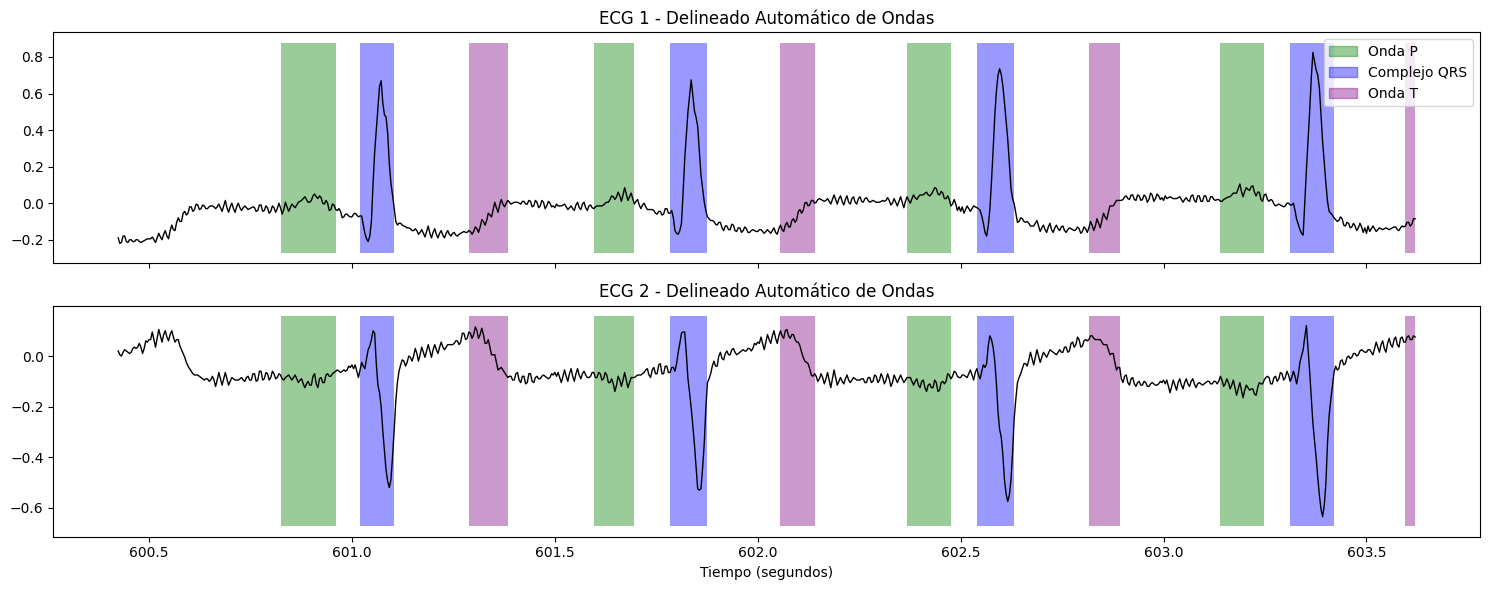

Clase 1 (P): 117
Clase 2 (QRS): 98
Clase 3 (T): 74


In [72]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. BUSCADOR AUTOMÁTICO DEL PRIMER LATIDO ANOTADO
# Buscamos dónde hay algún valor que no sea 0
indices_anotados = np.where(labels != 0)[0]
primer_indice_util = indices_anotados[0]

# Centramos nuestra ventana alrededor de ese latido 
# (ej: 200 puntos antes y 600 después para ver bien la onda)
inicio = primer_indice_util - 100
fin = primer_indice_util + 700

# 2. PREPARAR EL EJE DE TIEMPO
# (Asumimos que fs está definido, en QTDB suele ser 250)
tiempo = np.arange(inicio, fin) / 250

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

ax1.plot(tiempo, record.p_signal[inicio:fin, 0], color='black', linewidth=1)
ax2.plot(tiempo, record.p_signal[inicio:fin, 1], color='black', linewidth=1)

# Forzamos que matplotlib calcule los límites reales ANTES de fill_between
fig.canvas.draw()

ymin1, ymax1 = ax1.get_ylim()
ymin2, ymax2 = ax2.get_ylim()

colores_clases = {
    1: ('green',  'Onda P'),
    2: ('blue',   'Complejo QRS'),
    3: ('purple', 'Onda T')
}

for clase, (color, nombre) in colores_clases.items():
    mascara = (labels[inicio:fin] == clase)
    ax1.fill_between(tiempo, ymin1, ymax1, where=mascara, facecolor=color, alpha=0.4)
    ax2.fill_between(tiempo, ymin2, ymax2, where=mascara, facecolor=color, alpha=0.4)

ax1.set_title('ECG 1 - Delineado Automático de Ondas')
ax2.set_title('ECG 2 - Delineado Automático de Ondas')
ax2.set_xlabel('Tiempo (segundos)')

leyenda = [Patch(color=color, alpha=0.4, label=nombre) 
           for clase, (color, nombre) in colores_clases.items()]
ax1.legend(handles=leyenda, loc='upper right')

plt.tight_layout()
plt.show()
ventana = labels[inicio:fin]
print("Clase 1 (P):", np.sum(ventana == 1))
print("Clase 2 (QRS):", np.sum(ventana == 2))
print("Clase 3 (T):", np.sum(ventana == 3))


In [99]:
def create_window(signal, label, window_size=500, step=250, ratio_silencio=0.10):
    X = []
    y = []

    for i in range(0, len(signal) - window_size + 1, step):
        x_window = signal[i : i + window_size]
        y_window = label[i : i + window_size]

        has_wave = np.any(y_window > 0)

        if has_wave: # onda P, QRS o T
            X.append(x_window)
            y.append(y_window)
        else: # es silencio (cogemos un porcentaje)
            if np.random.random() < ratio_silencio:
                X.append(x_window)
                y.append(y_window)

    return np.array(X), np.array(y)

In [100]:
def apply_z_score(X_windows):
    """
    Recibe un array de ventanas (n_ventanas, 500, 2)
    y normaliza cada una de forma independiente.
    """
    # Calculamos media y std para cada ventana y cada canal
    mean = np.mean(X_windows, axis=1, keepdims=True)
    std = np.std(X_windows, axis=1, keepdims=True) + 1e-8
    return (X_windows - mean) / std

In [101]:
from scipy.signal import butter, filtfilt

def filtrar_ecg(signal, fs=250):
    """
    Aplica un filtro Butterworth pasa-banda (0.5Hz - 45Hz) para limpiar la señal.
    """
    nyq = 0.5 * fs

    low = 0.5 / nyq
    high = 45.0 / nyq
    
    b, a = butter(4, [low, high], btype='band')
    
    signal_filtrada = np.zeros_like(signal)
    for ch in range(signal.shape[1]):
        signal_filtrada[:, ch] = filtfilt(b, a, signal[:, ch])
        
    return signal_filtrada

In [102]:
def process_patients(patients_list):
    dir = "../data/qtdb_data/"
    X, y = [], []

    for patient in patients_list:
        record = wfdb.rdrecord(dir + patient)
        fs = record.fs
        ann = wfdb.rdann(dir + patient, "q1c")
        signal_length = len(record.p_signal)

        labels = wave_annotations(ann, signal_length)
        signal_pura = filtrar_ecg(record.p_signal, fs=fs)
        
        X_w, y_w = create_window(signal_pura, labels, ratio_silencio=0.25)
        
        X_w = apply_z_score(X_w)

        X.append(X_w)
        y.append(y_w)

    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)
    
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    return X[indices], y[indices]

In [103]:
patients_train = [
    'sel100', 'sel102', 'sel103', 'sel104', 'sel114',
    'sel116', 'sel117', 'sel123', 'sel213', 'sel221',
    'sel223', 'sel230', 'sel301', 'sel302', 'sel306',
    'sel307', 'sel803', 'sel808', 'sel811', 'sel820',
    'sel821', 'sel840', 'sel847', 'sel853', 'sel871',
    'sel872', 'sel16265', 'sel16272', 'sel16273', 'sel16420',
    'sel16483', 'sel16539', 'sel16773', 'sel16786', 'sele0104',
    'sele0106', 'sele0107', 'sele0110', 'sele0111', 'sele0112',
    'sele0114', 'sele0116', 'sele0121', 'sele0122', 'sele0124',
    'sele0126', 'sele0129', 'sele0133', 'sele0136', 'sele0166',
    'sele0170', 'sele0203', 'sele0210', 'sele0211', 'sele0303',
    'sele0405', 'sele0406', 'sele0409', 'sele0411', 'sele0509',
    'sele0603', 'sel30', 'sel31', 'sel32', 'sel33', 
    'sel34', 'sel35', 'sel36', 'sel37', 'sel38',
    'sel39', 'sel40', 'sel41', 'sel42', 'sel43',
    'sel44', 'sel45', 'sel46', 'sel47', 'sel48',
    'sel14046', 'sel14157'
]

patients_test = [
    'sel231', 'sel232', 'sel233', 'sel308', 'sel310',
    'sel873', 'sel883', 'sel891', 'sel16795', 'sel17453', 
    'sele0604', 'sele0606', 'sele0607', 'sele0609', 'sele0612',
    'sele0704', 'sel49', 'sel50', 'sel51', 'sel52',
    'sel17152', 'sel14172', 'sel15814'
]

data_dir = "../data"
npy_dir = os.path.join(data_dir, "npy_data_qtdb")

if not os.path.exists(npy_dir):
    print("Creating npy_dir folder")
    os.makedirs(npy_dir)
    X_train, y_train = process_patients(patients_train)
    X_test, y_test = process_patients(patients_test)
    np.save(os.path.join(npy_dir, "X_train_QT.npy"), X_train)
    np.save(os.path.join(npy_dir, "y_train_QT.npy"), y_train)
    np.save(os.path.join(npy_dir, "X_test_QT.npy"),  X_test)
    np.save(os.path.join(npy_dir, "y_test_QT.npy"),  y_test)
    print("Data saved.")
else:
    print("Data already exists, loading from disk...")
    X_train = np.load(os.path.join(npy_dir, "X_train_QT.npy"))
    y_train = np.load(os.path.join(npy_dir, "y_train_QT.npy"))
    X_test  = np.load(os.path.join(npy_dir, "X_test_QT.npy"))
    y_test  = np.load(os.path.join(npy_dir, "y_test_QT.npy"))

Creating npy_dir folder
Data saved.


In [106]:
'''
Esto cuando se pase a .py se puede quitar ya que se importará de forma directa (la función normalize)
'''
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, RepeatVector, TimeDistributed, UpSampling1D, Conv1DTranspose, Input, Bidirectional, concatenate, BatchNormalization, Dropout
from tensorflow.keras.layers import SpatialDropout1D, MultiHeadAttention, Add, LayerNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

'''
Modelo secuencial no es optimo ya que el kernel size es muy pequeño
model = Sequential()
model.add(Input(shape=(500, 2)))
model.add(Conv1D(filters=32, kernel_size=11, padding='same', activation='relu'))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(32, return_sequences=True)))
model.add(TimeDistributed(Dense(32, activation='relu')))
model.add(TimeDistributed(Dense(4, activation='softmax')))
'''
input_layer = Input(shape=(500, 2))

# Bloque multi-escala
conv_low = Conv1D(32, kernel_size=5,  padding="same", activation="relu")(input_layer)
conv_mid = Conv1D(32, kernel_size=15, padding="same", activation="relu")(input_layer)
conv_hi  = Conv1D(32, kernel_size=40, padding="same", activation="relu")(input_layer)
conv_total = concatenate([conv_low, conv_mid, conv_hi])
norm = BatchNormalization()(conv_total)

# BiLSTM 
lstm1 = Bidirectional(LSTM(128, return_sequences=True))(norm)
drop1 = SpatialDropout1D(0.3)(lstm1)
lstm2 = Bidirectional(LSTM(64, return_sequences=True))(drop1)
drop2 = SpatialDropout1D(0.3)(lstm2)

# Atención: 4 cabezas × key_dim=16 = 64 dimensiones (casa con la salida del BiLSTM(32))
attn_out = MultiHeadAttention(
    num_heads=4,
    key_dim=32,
    dropout=0.1
)(drop2, drop2)  

# Conexión residual — suma la entrada original con la salida de la atención
# Esto evita que la atención "destruya" lo que el LSTM ya aprendió
attn_out = Add()([drop2, attn_out])
attn_out = LayerNormalization()(attn_out)

# Bloque Conv1D de refinamiento post-LSTM
refine = Conv1D(32, kernel_size=5, padding="same", activation="relu")(attn_out)
refine = BatchNormalization()(refine)

output_layer = TimeDistributed(Dense(4, activation="softmax"))(refine)

model = Model(inputs=input_layer, outputs=output_layer)

model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 500, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 500, 32)   │        352 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 500, 32)   │        992 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 500, 32)   │      2,592 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 500, 96)   │          0 │ conv1d_22[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_23[0][0],  │
│                     │                   │            │ conv1d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 96)   │        384 │ concatenate_5[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_10    │ (None, 500, 256)  │    230,400 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 500, 256)  │          0 │ bidirectional_10… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_11    │ (None, 500, 128)  │    164,352 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_… │ (None, 500, 128)  │          0 │ bidirectional_11… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 500, 128)  │     66,048 │ spatial_dropout1… │
│ (MultiHeadAttentio… │                   │            │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 500, 128)  │          0 │ spatial_dropout1… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 500, 128)  │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 500, 32)   │     20,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 500, 32)   │        128 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 500, 4)    │        132 │ batch_normalizat… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 486,148 (1.85 MB)

 Trainable params: 485,892 (1.85 MB)

 Non-trainable params: 256 (1.00 KB)

In [118]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

TRAIN_MODEL = True  # cambiar a True para reentrenar

weights_map = {0: 0.3, 1: 1.5, 2: 2.0, 3: 3}
sample_weights = np.vectorize(weights_map.get)(y_train)

model.compile(
    optimizer=Adam(learning_rate=1e-3), #lr demasiado alto, bajar a la mitad o probar con menos
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5, 
    min_lr=1e-6,
    verbose=1
)

model_save = ModelCheckpoint(
    filepath = "../models/labeling_v2_multihead.keras",
    save_best_only = True,
    verbose = 1,
    monitor = "val_loss"
)

print("Starting training...")
history = model.fit(
    X_train,
    y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_test, y_test),
    sample_weight=sample_weights,
    callbacks=[early_stop, reduce_lr, model_save]
)

Starting training...
Epoch 1/200
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.8892 - loss: 0.1112
Epoch 1: val_loss improved from None to 0.22273, saving model to ../models/labeling_v2_multihead.keras

Epoch 1: finished saving model to ../models/labeling_v2_multihead.keras
649/649 ━━━━━━━━━━━━━━━━━━━━ 585s 878ms/step - accuracy: 0.8888 - loss: 0.1115 - val_accuracy: 0.9234 - val_loss: 0.2227 - learning_rate: 0.0010
Epoch 2/200
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - accuracy: 0.8895 - loss: 0.1152
Epoch 2: val_loss did not improve from 0.22273
649/649 ━━━━━━━━━━━━━━━━━━━━ 559s 862ms/step - accuracy: 0.8893 - loss: 0.1140 - val_accuracy: 0.9030 - val_loss: 0.2440 - learning_rate: 0.0010
Epoch 3/200
649/649 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.8938 - loss: 0.1130
Epoch 3: val_loss did not improve from 0.22273
649/649 ━━━━━━━━━━━━━━━━━━━━ 567s 874ms/step - accuracy: 0.8909 - loss: 0.1142 - val_accuracy: 0.9098 - val_loss: 0.2460 - learning_rate: 0.0010
Epoch 4

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


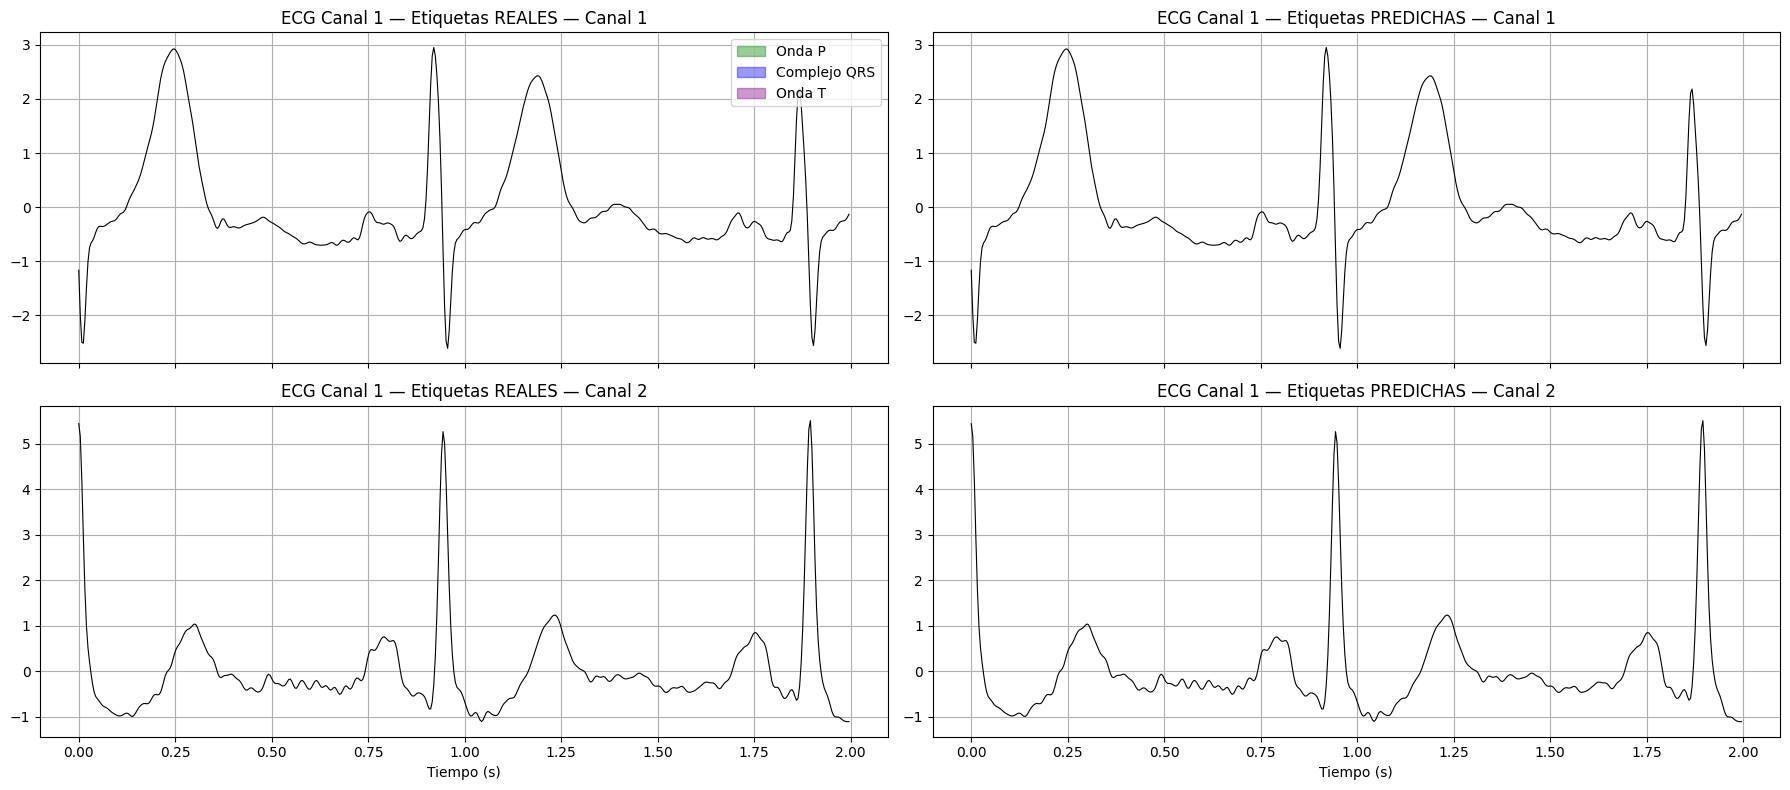

Accuracy en esta ventana: 1.0000
Clase 1 (P)  — Real:   0 | Pred:   0
Clase 2 (QRS)— Real:   0 | Pred:   0
Clase 3 (T)  — Real:   0 | Pred:   0
Clase 0 (BL) — Real: 500 | Pred: 500


In [120]:
from tensorflow.keras.models import load_model

model = load_model("../models/labeling_v2_multihead.keras", compile=False)

indice = 78

x_ventana = X_test[indice:indice+1]  # shape (1, 500, 2)

# Predecimos — salida shape (1, 500, 4) con probabilidades por clase
pred = model.predict(x_ventana)

# Cogemos la clase con   mayor probabilidad para cada muestra
pred_clases = np.argmax(pred[0], axis=-1)  # shape (500,)
y_real      = y_test[indice, :]         # shape (500,) — quitamos la dimensión extra

tiempo = np.arange(500) / 250  # eje de tiempo en segundos

colores_clases = {
    1: ('green',  'Onda P'),
    2: ('blue',   'Complejo QRS'),
    3: ('purple', 'Onda T')
}

fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=True)

titulos = [
    ('ECG Canal 1 — Etiquetas REALES',     y_real,      axes[0, 0], axes[1, 0]),
    ('ECG Canal 1 — Etiquetas PREDICHAS',  pred_clases, axes[0, 1], axes[1, 1]),
]

for titulo, etiquetas, ax1, ax2 in titulos:
    ax1.plot(tiempo, X_test[indice][:, 0], color='black', linewidth=0.8)
    ax2.plot(tiempo, X_test[indice][:, 1], color='black', linewidth=0.8)

    fig.canvas.draw()
    ymin1, ymax1 = ax1.get_ylim()
    ymin2, ymax2 = ax2.get_ylim()

    for clase, (color, nombre) in colores_clases.items():
        mascara = (etiquetas == clase)
        ax1.fill_between(tiempo, ymin1, ymax1, where=mascara, facecolor=color, alpha=0.4)
        ax2.fill_between(tiempo, ymin2, ymax2, where=mascara, facecolor=color, alpha=0.4)

    ax1.set_title(f'{titulo} — Canal 1')
    ax2.set_title(f'{titulo} — Canal 2')
    ax1.grid(True)
    ax2.grid(True)

from matplotlib.patches import Patch
leyenda = [Patch(color=c, alpha=0.4, label=n) for _, (c, n) in colores_clases.items()]
axes[0, 0].legend(handles=leyenda)

axes[1, 0].set_xlabel('Tiempo (s)')
axes[1, 1].set_xlabel('Tiempo (s)')

plt.tight_layout()
plt.show()

# Métricas rápidas
print(f"Accuracy en esta ventana: {np.mean(pred_clases == y_real):.4f}")
print(f"Clase 1 (P)  — Real: {np.sum(y_real==1):3d} | Pred: {np.sum(pred_clases==1):3d}")
print(f"Clase 2 (QRS)— Real: {np.sum(y_real==2):3d} | Pred: {np.sum(pred_clases==2):3d}")
print(f"Clase 3 (T)  — Real: {np.sum(y_real==3):3d} | Pred: {np.sum(pred_clases==3):3d}")
print(f"Clase 0 (BL) — Real: {np.sum(y_real==0):3d} | Pred: {np.sum(pred_clases==0):3d}")

In [121]:
# Ventanas donde el modelo no predice NADA (todo silencio)
pred_all = model.predict(X_test)
pred_clases = np.argmax(pred_all, axis=-1)

ventanas_vacias = np.where(np.all(pred_clases == 0, axis=1))[0]
ventanas_con_ondas_reales = np.where(np.any(y_test > 0, axis=1))[0]

# Cuántas ventanas vacías deberían tener ondas
fallos_graves = np.intersect1d(ventanas_vacias, ventanas_con_ondas_reales)
print(f"Ventanas con ondas reales donde predice todo silencio: {len(fallos_graves)}")
print(f"Porcentaje: {len(fallos_graves)/len(ventanas_con_ondas_reales)*100:.1f}%")

183/183 ━━━━━━━━━━━━━━━━━━━━ 125s 672ms/step
Ventanas con ondas reales donde predice todo silencio: 586
Porcentaje: 69.7%


In [115]:
pred_all = model.predict(X_test)

for umbral in [0.4, 0.5, 0.6, 0.7]:
    pred_clases = np.zeros(pred_all.shape[:2], dtype=int)
    for clase in [1, 2, 3]:
        pred_clases[pred_all[:, :, clase] > umbral] = clase
    
    print(f"\n--- Umbral {umbral} ---")
    print(classification_report(
        y_test.flatten(), pred_clases.flatten(),
        target_names=['Silencio', 'Onda P', 'QRS', 'Onda T']
    ))

183/183 ━━━━━━━━━━━━━━━━━━━━ 118s 643ms/step

--- Umbral 0.4 ---
              precision    recall  f1-score   support

    Silencio       0.97      0.83      0.90   2806156
      Onda P       0.10      0.52      0.17     41164
         QRS       0.11      0.53      0.18     44636
      Onda T       0.06      0.15      0.09     34044

    accuracy                           0.82   2926000
   macro avg       0.31      0.51      0.33   2926000
weighted avg       0.93      0.82      0.87   2926000


--- Umbral 0.5 ---
              precision    recall  f1-score   support

    Silencio       0.97      0.85      0.91   2806156
      Onda P       0.10      0.48      0.17     41164
         QRS       0.11      0.48      0.17     44636
      Onda T       0.06      0.14      0.09     34044

    accuracy                           0.83   2926000
   macro avg       0.31      0.49      0.33   2926000
weighted avg       0.93      0.83      0.87   2926000


--- Umbral 0.6 ---
              precision  